In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

#df = pd.read_csv("dataset/LD2011_2014.txt", delimiter=";", decimal=",")
#df["Time"] = pd.to_datetime(df.pop("Unnamed: 0"), format="%Y-%m-%d %H:%M:%S")
#df = df.set_index("Time")
tt_split = 0.8

df = pd.read_csv("https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv").drop(
    columns=["date"])
split_index = int(df.shape[0] * tt_split)
df_train = df[:split_index]
df_test = df[:split_index]
mn = df_train.mean()
st = df_train.std()
df_train = (df_train - mn) / st
df_test = (df_test - mn) / st

In [43]:
from torch.utils.data import Dataset


class TimeDataset(Dataset):
    def __init__(self,
                 df,
                 seq_len=96,
                 pred_len=24):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.data = df.values.astype(np.float32)

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, idx):
        x = self.data[idx: idx + self.seq_len]
        y = self.data[idx + self.seq_len: idx + self.seq_len + self.pred_len]

        return torch.tensor(x), torch.tensor(y)

In [106]:
import math

class RevIN(nn.Module):
    def __init__(self):
        super().__init__()
        self.mean = None
        self.std = None
        self.eps = 1e-5
        
    def forward(self, x, mode="norm"):
        if mode == "norm":
            self.mean = x.mean(dim=1, keepdims=True).detach()
            self.std = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            return (x - self.mean) / self.std
        if mode == "denorm":
            return x * self.std + self.mean
            

class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 100):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class Patching(nn.Module):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.patch = nn.Conv1d(1, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, L, N = x.shape
        channel_independent = x.reshape((B * N), 1, L)
        return self.patch(channel_independent).permute(0, 2, 1)


class PatchTST(nn.Module):
    def __init__(self, lookback_len, pred_len, patch_size, embed_dim, num_layers=2):
        super().__init__()
        self.lookback_len = lookback_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.revin = RevIN()
        self.patching = Patching(patch_size, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len=(lookback_len // patch_size + 1))
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, 4, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        patch_len_lookback = lookback_len // patch_size
        self.head = nn.Linear(patch_len_lookback * embed_dim, pred_len)

    def forward(self, x):
        B, L, N = x.shape
        x = self.revin(x)
        patched = self.patching(x)
        encoder_input = self.pos_encoding(patched)
        encoded = self.encoder(encoder_input)
        out = self.head(encoded.reshape(B, N, -1)).permute(0, 2, 1)
        return self.revin(out, "denorm")





In [107]:
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm import trange
from tqdm import tqdm

torch.set_float32_matmul_precision('high')

lookback = 96
pred_len = 96

dataset_train = TimeDataset(df_train, seq_len=lookback, pred_len=pred_len)
dataset_test = TimeDataset(df_test, seq_len=lookback, pred_len=pred_len)
model = PatchTST(lookback, pred_len, 8, 32)

optim = AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

loader_train = DataLoader(dataset_train, batch_size=64, shuffle=True, drop_last=True)
loader_test = DataLoader(dataset_test, batch_size=64, drop_last=True)

train_fn = nn.MSELoss()

for i in range(50):
    total_loss = 0
    count = 0
    model.train()
    for x, y in tqdm(loader_train):
        optim.zero_grad()
        pred = model(x)
        loss = train_fn(pred, y)
        total_loss += loss.item()
        count += 1
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
    print(f"Training {total_loss / count}")
    model.eval()
    total_loss = 0
    count = 0
    with torch.no_grad():
        for x, y in loader_test:
            pred = model(x)
            loss = train_fn(pred, y)
            total_loss += loss.item()
            count += 1
        
        print(f"Test {total_loss / count}")

100%|██████████| 214/214 [01:52<00:00,  1.90it/s]


Training 0.5326150439888517
Test 0.48513171605974714


100%|██████████| 214/214 [01:49<00:00,  1.96it/s]


Training 0.48271021232983774
Test 0.4598386945707776


100%|██████████| 214/214 [01:46<00:00,  2.02it/s]


...

Training 0.40830643976403175
Test 0.38210112552776515


100%|██████████| 214/214 [01:47<00:00,  1.99it/s]


Training 0.40655553689069834
Test 0.3812492072721508


  2%|▏         | 5/214 [00:02<02:03,  1.69it/s]


KeyboardInterrupt: 

In [82]:
model = PatchTST(lookback, pred_len, 8, 32)
model.load_state_dict(torch.load("checkpoint.pt"))

<All keys matched successfully>

In [108]:
import functools

attn_maps = {}

def patch_mha(module, name):
    original_forward = module.forward

    @functools.wraps(original_forward)
    def patched_forward(*args, **kwargs):
        kwargs['need_weights'] = True
        kwargs['average_attn_weights'] = False
        return original_forward(*args, **kwargs)
    
    module.forward = patched_forward

def make_hook(name):
    def hook_fn(module, input, output):
        # output = (attn_output, attn_weights)
        if isinstance(output, tuple) and len(output) == 2:
            attn_maps[name] = output[1].detach()
    return hook_fn

for name, module in model.named_modules():
    if isinstance(module, nn.MultiheadAttention):
        patch_mha(module, name)
        module.register_forward_hook(make_hook(name))


x tensor([[ 0.2886,  0.6125,  0.2848,  0.4479, -0.0436,  1.1197,  2.1667],
        [ 0.2189,  0.4776,  0.2604,  0.3712, -0.0713,  1.2248,  2.1718],
        [ 0.1848,  0.3219,  0.2795,  0.3708,  0.1556,  1.2997,  2.1907],
        [ 0.1756,  0.1607,  0.3348,  0.4034,  0.2496,  1.2104,  2.1634],
        [ 0.2041,  0.0797,  0.3868,  0.4525,  0.3881,  1.1381,  2.1636],
        [ 0.2663,  0.0993,  0.4127,  0.4628,  0.4570,  0.9588,  2.1670],
        [ 0.3457,  0.1623,  0.4306,  0.4913,  0.4702,  0.7089,  2.1720],
        [ 0.4299,  0.3090,  0.4434,  0.4666,  0.3846,  0.4741,  2.1495],
        [ 0.5028,  0.4995,  0.4441,  0.4272,  0.3885,  0.3796,  2.1197],
        [ 0.5957,  0.7000,  0.4691,  0.4826,  0.2922,  0.3491,  2.0727],
        [ 0.6535,  0.8934,  0.5579,  0.5755,  0.1960,  0.3676,  2.0427],
        [ 0.6692,  1.0448,  0.6340,  0.6746,  0.2797,  0.4982,  2.0056],
        [ 0.6419,  1.0707,  0.6430,  0.7668,  0.5086,  0.5946,  1.9869],
        [ 0.6341,  1.1593,  0.6428,  0.8636,  0.5

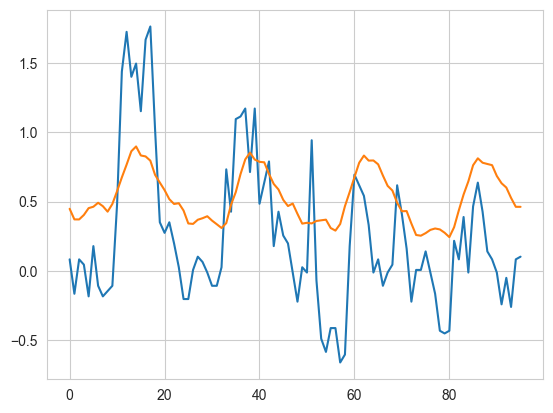

In [119]:
dataset_test = TimeDataset(df_test, seq_len=lookback, pred_len=pred_len)
var = 3

x, y = dataset_test[180]
pred = model(x.unsqueeze(0)).squeeze(0)
print("x", pred)
plt.plot(y[:, var])
plt.plot(pred[:, var].detach())
plt.show()

In [87]:
pred

tensor([[ 4.4768e-01,  4.1764e-01,  2.2397e-01,  4.8169e-01, -1.3869e-01,
          1.2890e+00,  1.7068e+00],
        [ 3.5094e-01,  4.9170e-01,  3.2020e-01,  5.2816e-01, -3.2408e-02,
          1.2864e+00,  1.7542e+00],
        [ 2.4670e-01,  5.8369e-01,  3.5137e-01,  5.4217e-01,  4.5117e-02,
          1.2407e+00,  1.7060e+00],
        [ 2.0483e-01,  6.9586e-01,  4.1898e-01,  5.8505e-01,  1.7485e-01,
          1.2523e+00,  1.7803e+00],
        [ 1.9116e-01,  7.8188e-01,  3.9226e-01,  5.8342e-01,  1.7121e-01,
          1.2246e+00,  1.7334e+00],
        [ 1.8564e-01,  8.6863e-01,  4.1290e-01,  5.6514e-01,  2.1224e-01,
          1.2007e+00,  1.7938e+00],
        [ 2.1595e-01,  9.0627e-01,  4.2289e-01,  5.9120e-01,  1.8563e-01,
          1.1867e+00,  1.7981e+00],
        [ 3.1715e-01,  1.0139e+00,  4.2682e-01,  6.2404e-01,  1.9281e-01,
          1.2551e+00,  1.8796e+00],
        [ 3.9406e-01,  1.0507e+00,  4.4198e-01,  5.8351e-01,  2.2534e-01,
          1.1663e+00,  1.9002e+00],
        [ 

['encoder.layers.0.self_attn', 'encoder.layers.1.self_attn']
encoder.layers.1.self_attn


<Axes: >

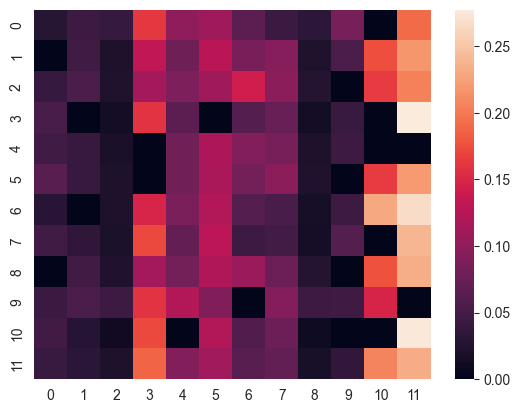

In [110]:
import seaborn as sns

keys = list(attn_maps.keys())
print(keys)
layer_num = 1
var_num = 0
head_num = 3

print(keys[layer_num])
sns.heatmap(attn_maps[keys[layer_num]][var_num, head_num])

In [76]:
torch.save(model.state_dict(), "checkpoint.pt")